# ENVIRONMENT SETUP

In [1]:
!pip install torch_geometric ogb -q

import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import time
from ogb.nodeproppred import PygNodePropPredDataset
import torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.0 MB/s eta 0:00:00


In [2]:
# fix for PyTorch 2.6+: torch.load defaults to weights_only=True, which blocks the older torch_geometric classes used inside the OGB cached .pt file. allowlisting these classes lets the trusted OGB file load normally (safe here since the file comes from our own download, not an untrusted third party)
torch.serialization.add_safe_globals([
    torch_geometric.data.data.DataEdgeAttr,
    torch_geometric.data.data.DataTensorAttr,
    torch_geometric.data.storage.GlobalStorage
])

In [3]:
# loading the full graph (~169,000 nodes, ~1.1 million citation links).takes noticeable time - this is expected given the dataset scale

start_time=time.time()

dataset=PygNodePropPredDataset(name='ogbn-arxiv',root='data/')
data=dataset[0]

print(data)
print("dataset loaded in",round(time.time()-start_time,2),"seconds")

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:03<00:00, 26.27it/s]


Extracting data/arxiv.zip


Processing...


Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 8756.38it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 290.59it/s]

Saving...
Data(num_nodes=169343, edge_index=[2, 1166243], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
dataset loaded in 14.08 seconds



Done!


# TASK 02 - GRAPH REPRESENTATION AND ANALYSIS

## Step 1. Represent the graph as an edge list

In [4]:
edge_index=data.edge_index.numpy()
edge_list=pd.DataFrame({'source':edge_index[0],'target':edge_index[1]})
print(edge_list.head())
print("total edges:",len(edge_list))

# building the NetworkX graph also takes time for ~1.1M edges, this is expected and can be mentioned in the report
g=nx.Graph()
g.add_edges_from(edge_list.values.tolist())
print("graph built with",g.number_of_nodes(),"nodes and",g.number_of_edges(),"edges")

   source  target
0  104447   13091
1   15858   47283
2  107156   69161
3  107156  136440
4  107156  107366
total edges: 1166243
graph built with 169343 nodes and 1157799 edges


## Step 2. Visualize a sample subgraph

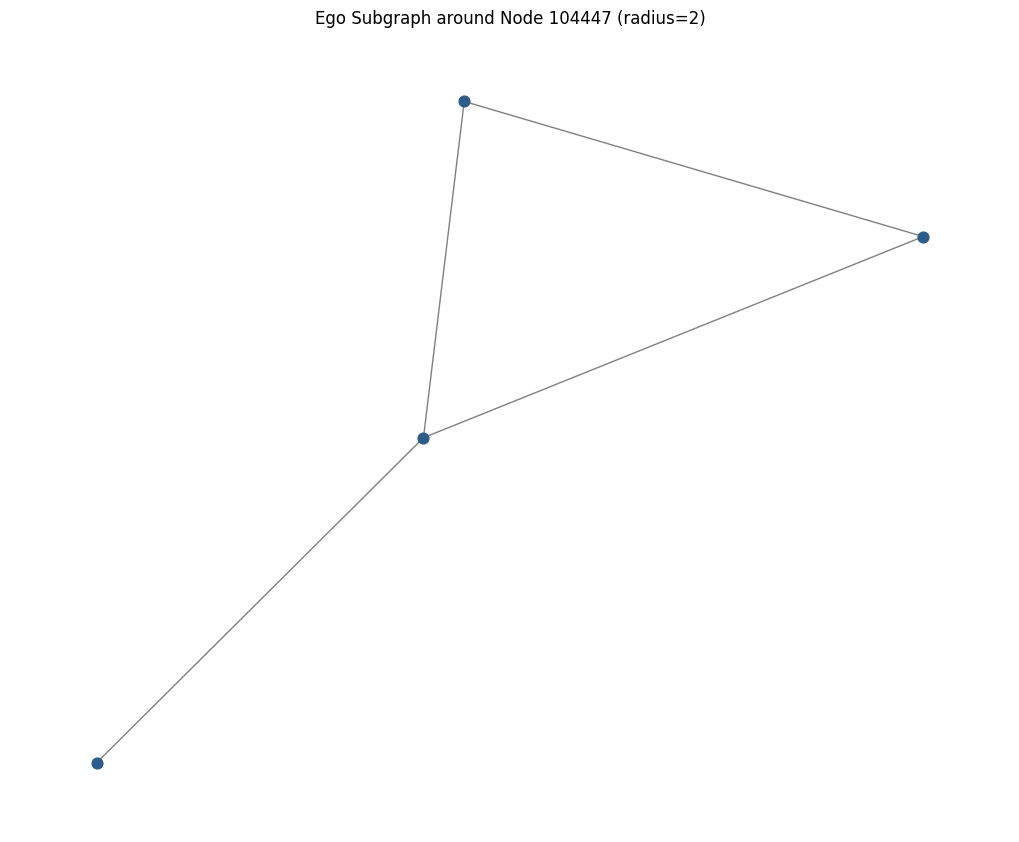

nodes in ego subgraph: 4
edges in ego subgraph: 4


In [5]:
# previous version sampled the first 50 nodes directly, which pulled disconnected fragments from all over the graph and looked scattered.

center_node=list(g.nodes())[0]
ego_subgraph=nx.ego_graph(g,center_node,radius=2)

plt.figure(figsize=(10,8))
nx.draw(ego_subgraph,node_size=60,with_labels=False,edge_color='gray',
        node_color='#2E5C8A')
plt.title(f"Ego Subgraph around Node {center_node} (radius=2)")
plt.show()

print("nodes in ego subgraph:",ego_subgraph.number_of_nodes())
print("edges in ego subgraph:",ego_subgraph.number_of_edges())


## Step 3. Describe node features

In [6]:
# Display feature matrix and shapes
print("feature matrix shape:",data.x.shape)
print("feature vector sample:",data.x[0])
print("feature mean:",data.x.mean().item())
print("feature std:",data.x.std().item())

feature matrix shape: torch.Size([169343, 128])
feature vector sample: tensor([-0.0579, -0.0525, -0.0726, -0.0266,  0.1304, -0.2414, -0.4492, -0.0184,
        -0.0872,  0.1123, -0.0921, -0.2896, -0.0810,  0.0745, -0.1562, -0.0974,
         0.1194,  0.6458,  0.0774, -0.0939, -0.4004,  0.3114, -0.5418,  0.0805,
        -0.0069,  0.5423, -0.0122, -0.1808,  0.0165,  0.0508, -0.2083, -0.0870,
         0.0124,  0.2817,  0.1004, -0.1643,  0.0269,  0.0782,  0.0795, -0.0134,
         0.2915,  0.0416, -0.1414, -0.1345,  0.0162,  0.2810, -0.0919, -0.2403,
         0.4618,  0.1873,  0.1533,  0.0331,  0.0108,  0.0124, -0.1589,  0.0980,
         0.0305,  0.0162, -0.0957,  0.0521,  0.3218, -0.1057,  0.2229, -0.1206,
        -0.1723,  0.3954,  0.0883, -0.2219,  0.2310, -0.2096, -0.1125, -0.0644,
         0.0697, -0.1574,  0.0223, -0.4190,  0.1344,  0.2605,  0.0417, -0.0935,
        -0.0516, -0.0255,  0.7744,  0.0581,  0.0452,  0.0571, -0.5482, -0.0464,
         0.8728,  0.0119,  0.3891, -0.0859,  0.11

### Node Feature Interpretation
Each node represents a paper, and its 128-dimensional feature vector is a Word2Vec-style skip-gram embedding averaged over the words in the paper's title and abstract. This means each feature vector captures the paper's semantic content, while the graph edges capture citation relationships — the two are complementary signals for the downstream classification task. The features are dense, real-valued, and centered close to zero, which makes them directly usable by distance-based and neural models without further encoding.

## Step 4. Degree Distribution Analysis

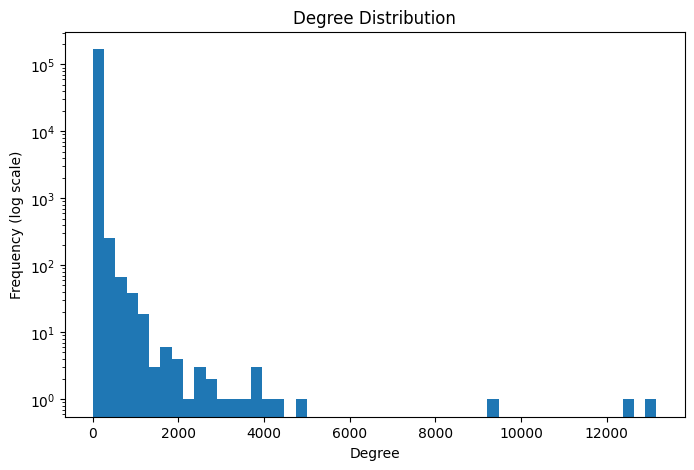

average degree: 13.674010735607613
max degree: 13161


In [7]:
# Degree Distribution analysis
degrees=[d for n,d in g.degree()]

plt.figure(figsize=(8,5))
plt.hist(degrees,bins=50,log=True)
plt.xlabel("Degree")
plt.ylabel("Frequency (log scale)")
plt.title("Degree Distribution")
plt.show()

print("average degree:",np.mean(degrees))
print("max degree:",np.max(degrees))

## Step 5. Graph Density Analysis

In [8]:
# Display Graph Density
n=g.number_of_nodes()
e=g.number_of_edges()
density=(2*e)/(n*(n-1))
print("graph density:",density)

graph density: 8.074789913670332e-05


## Step 6. Connected Component Analysis

In [9]:
# nx.connected_components treats the graph as undirected even though citations are directed - stated explicitly here
components=list(nx.connected_components(g))
print("number of connected components:",len(components))
largest=max(components,key=len)
print("largest component size:",len(largest))
print("largest component % of graph:",len(largest)/n*100)

number of connected components: 1
largest component size: 169343
largest component % of graph: 100.0


### Graph Structure Analysis Summary
- **Degree distribution:** highly right-skewed on a log scale — most papers cite or are cited by only a handful of others, while a small number of highly-cited "hub" papers have very large degree. This is the typical power-law-like pattern seen in citation networks.
- **Density:** ~8.07e-05, i.e. extremely sparse — the graph is nowhere near fully connected pairwise, which is expected since each paper only cites a small subset of the ~169k available papers.
- **Connected components:** exactly 1 component containing 100% of nodes, so the (undirected) graph is fully connected. This is favorable for GNN training, since message passing can propagate information across the entire graph without isolated subgraphs being cut off from label information.

# TASK 03 - GRAPH DATA PREPARATION

##  Step 1. Load node features

In [10]:
features=data.x
print("features shape:",features.shape)

features shape: torch.Size([169343, 128])


##  Step 2. Load labels

In [11]:
labels=data.y.squeeze()
print("labels shape:",labels.shape)
print("number of classes:",labels.max().item()+1)

labels shape: torch.Size([169343])
number of classes: 40


## Step 3. Create training, validation, and test splits

In [12]:
# using OGB's official split  instead of a random split - this avoids data leakage since earlier papers are used for training and later papers for testing
split_idx=dataset.get_idx_split()
train_idx=split_idx['train']
valid_idx=split_idx['valid']
test_idx=split_idx['test']

print("train size:",len(train_idx))
print("valid size:",len(valid_idx))
print("test size:",len(test_idx))

train size: 90941
valid size: 29799
test size: 48603


##  Step 4. Normalize features

In [13]:
# mean and std are computed from the TRAINING set only, then applied to all nodes.
mean=features[train_idx].mean(dim=0)
std=features[train_idx].std(dim=0)
features_norm=(features-mean)/std

data.x=features_norm

print("normalized feature mean (train):",features_norm[train_idx].mean().item())
print("normalized feature std (train):",features_norm[train_idx].std().item())


normalized feature mean (train): 1.6488344911635977e-08
normalized feature std (train): 0.9999945163726807


### Preprocessing Decisions Explained
- **Splits:** OGB's official train/valid/test split is used instead of a random split, because it is a *temporal* split (train = papers published before 2017, valid = 2017, test = 2018 and later). This avoids information leakage and mirrors the realistic setting of predicting the category of newly published papers using only past papers.
- **Normalization:** Feature mean and standard deviation are computed using only the training split (`train_idx`), then applied to standardize every node (train, validation, and test). Fitting the scaler on the full dataset would leak validation/test distribution information into training, so statistics are deliberately restricted to the training indices.
- **No imputation needed:** The 128-dim embeddings are dense, precomputed and complete (no missing values), so no imputation step is required before normalization.
- **Why standardize (z-score) rather than min-max:** the skip-gram embeddings are roughly Gaussian-distributed around zero rather than bounded, so z-score standardization is more appropriate than min-max scaling to 0-1.

# Step 6. Save processed data

In [14]:
# saving so preprocessing the whole pipeline every time to continue tasks
processed={
    'features':data.x,
    'labels':labels,
    'edge_index':data.edge_index,
    'train_idx':train_idx,
    'valid_idx':valid_idx,
    'test_idx':test_idx
}

with open('processed_data.pkl','wb') as f:
    pickle.dump(processed,f)

print("saved processed_data.pkl")

saved processed_data.pkl
